In [1]:
!pip install streamlit pyngrok


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 37.0 MB/s eta 0:00:00


In [57]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,roc_curve,roc_auc_score,auc
from sklearn.feature_selection import SelectKBest,f_classif
import streamlit as st
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

In [58]:
df=pd.read_csv("/content/heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [59]:
df['target']=df['num'].apply(lambda x:1 if x>0 else 0)
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,target
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,0


In [60]:
df.shape

(920, 17)

In [61]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [62]:
df[['fbs','exang']]=df[['fbs','exang']].fillna(df[['fbs','exang']].mode().iloc[0]).astype(int)


/tmp/ipykernel_599/2973680026.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[['fbs','exang']]=df[['fbs','exang']].fillna(df[['fbs','exang']].mode().iloc[0]).astype(int)


In [63]:
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,target
0,1,63,Male,Cleveland,typical angina,145.0,233.0,1,lv hypertrophy,150.0,0,2.3,downsloping,0.0,fixed defect,0,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,0,lv hypertrophy,108.0,1,1.5,flat,3.0,normal,2,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,0,lv hypertrophy,129.0,1,2.6,flat,2.0,reversable defect,1,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,0,normal,187.0,0,3.5,downsloping,0.0,normal,0,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,0,lv hypertrophy,172.0,0,1.4,upsloping,0.0,normal,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,1,st-t abnormality,154.0,0,0.0,NaN,NaN,NaN,1,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,0,st-t abnormality,NaN,0,NaN,NaN,NaN,NaN,0,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,1,st-t abnormality,100.0,0,0.0,NaN,NaN,fixed defect,2,1
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,1,lv hypertrophy,NaN,0,NaN,NaN,NaN,NaN,0,0


In [64]:
df=pd.get_dummies(df,columns=['cp','dataset','restecg','thal','slope','sex'],drop_first=True,dtype=int)


In [65]:
df

,id,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,num,target,cp_atypical angina,cp_non-anginal,cp_typical angina,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,restecg_normal,restecg_st-t abnormality,thal_normal,thal_reversable defect,slope_flat,slope_upsloping,sex_Male
0,1,63,145.0,233.0,1,150.0,0,2.3,0.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1
1,2,67,160.0,286.0,0,108.0,1,1.5,3.0,2,1,0,0,0,0,0,0,0,0,1,0,1,0,1
2,3,67,120.0,229.0,0,129.0,1,2.6,2.0,1,1,0,0,0,0,0,0,0,0,0,1,1,0,1
3,4,37,130.0,250.0,0,187.0,0,3.5,0.0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1
4,5,41,130.0,204.0,0,172.0,0,1.4,0.0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,127.0,333.0,1,154.0,0,0.0,NaN,1,1,0,0,0,0,0,1,0,1,0,0,0,0,0
916,917,62,NaN,139.0,0,NaN,0,NaN,NaN,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1
917,918,55,122.0,223.0,1,100.0,0,0.0,NaN,2,1,0,0,0,0,0,1,0,1,0,0,0,0,1
918,919,58,NaN,385.0,1,NaN,0,NaN,NaN,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        920 non-null    int64  
 1   age                       920 non-null    int64  
 2   trestbps                  861 non-null    float64
 3   chol                      890 non-null    float64
 4   fbs                       920 non-null    int64  
 5   thalch                    865 non-null    float64
 6   exang                     920 non-null    int64  
 7   oldpeak                   858 non-null    float64
 8   ca                        309 non-null    float64
 9   num                       920 non-null    int64  
 10  target                    920 non-null    int64  
 11  cp_atypical angina        920 non-null    int64  
 12  cp_non-anginal            920 non-null    int64  
 13  cp_typical angina         920 non-null    int64  
 14  dataset_Hu

In [68]:
df=df.drop('num',axis=1)

In [69]:
df.corr()['target'].abs().sort_values(ascending=False).head(10)

,target
target,1.000000
ca,0.455599
exang,0.433605
cp_atypical angina,0.403465
thalch,0.394503
oldpeak,0.385528
id,0.356086
slope_flat,0.339273
sex_Male,0.307284
dataset_Switzerland,0.301614


In [70]:
X = df.drop('target', axis=1)
y = df['target']

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (920, 22)
y shape: (920,)


In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [72]:
imputer = SimpleImputer(strategy='mean')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


In [73]:
k = min(10, X_train.shape[1])

kBest = SelectKBest(
    score_func=f_classif,
    k=k
)

In [74]:
X_train_selected = kBest.fit_transform(X_train,y_train)

X_test_selected = kBest.transform(X_test)

In [75]:
selected_features = X.columns[kBest.get_support()].tolist()

print("\nSelected Features:")
for feature in selected_features:
    print(feature)


Selected Features:
id
age
thalch
exang
oldpeak
ca
cp_atypical angina
dataset_Switzerland
slope_flat
sex_Male


In [76]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_selected
)

X_test_scaled = scaler.transform(
    X_test_selected
)

Logistic Regression

In [80]:
log_reg=LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled,y_train)


LogisticRegression(max_iter=1000)

In [81]:
y_pred_log=log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(
    X_test_scaled
)[:, 1]
print("Accuracy:",accuracy_score(y_test,y_pred_log))
print("confusion Matrix",confusion_matrix(y_test,y_pred_log))
print("Precision:",precision_score(y_test,y_pred_log))
print("Recall:",recall_score(y_test,y_pred_log))
print("F1 Score:",f1_score(y_test,y_pred_log))

Accuracy: 0.842391304347826
confusion Matrix [[66 16]
 [13 89]]
Precision: 0.8476190476190476
Recall: 0.8725490196078431
F1 Score: 0.8599033816425121


<Axes: >

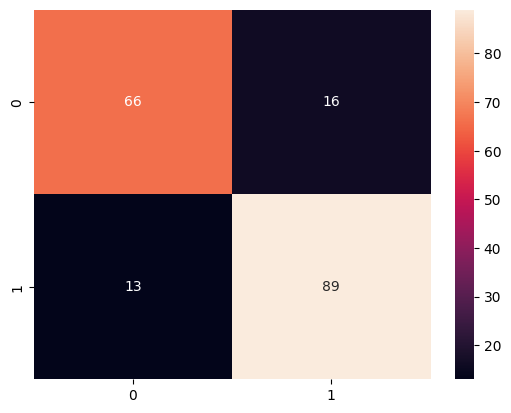

In [82]:
sns.heatmap(confusion_matrix(y_test,y_pred_log),annot=True)

In [96]:
print(
        "ROC-AUC:",
        roc_auc_score(y_test, y_prob_log)
    )

ROC-AUC: 0.9036346245815399


RandomForest

In [83]:
RanForst=RandomForestClassifier(n_estimators=100,random_state=42)
RanForst.fit(X_train_scaled,y_train)

RandomForestClassifier(random_state=42)

In [85]:
y_pred_ran=RanForst.predict(X_test_scaled)
y_prob_rf = RanForst.predict_proba(
    X_test_scaled
)[:, 1]
print("Accuracy:",accuracy_score(y_test,y_pred_ran))
print("confusion Matrix",confusion_matrix(y_test,y_pred_ran))
print("Precision:",precision_score(y_test,y_pred_ran))
print("Recall:",recall_score(y_test,y_pred_ran))
print("F1 Score:",f1_score(y_test,y_pred_ran))

Accuracy: 0.8913043478260869
confusion Matrix [[67 15]
 [ 5 97]]
Precision: 0.8660714285714286
Recall: 0.9509803921568627
F1 Score: 0.9065420560747663


<Axes: >

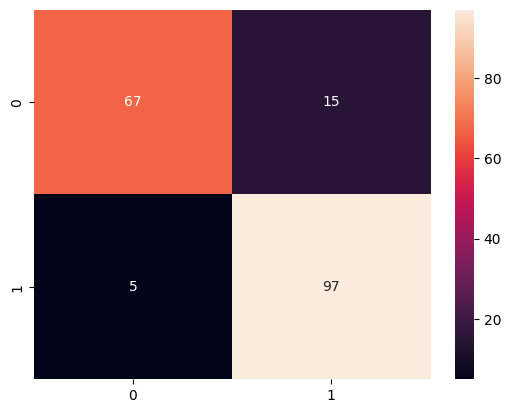

In [86]:
sns.heatmap(confusion_matrix(y_test,y_pred_ran),annot=True)

In [95]:
print(
        "ROC-AUC:",
        roc_auc_score(y_test, y_prob_rf)
    )

ROC-AUC: 0.9329268292682926


DescionTree

In [87]:
tree=DecisionTreeClassifier(criterion='entropy',random_state=42)
tree.fit(X_train_scaled,y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [88]:
y_pred_tree=tree.predict(X_test_scaled)
y_prob_tree = tree.predict_proba(
    X_test_scaled
)[:, 1]
print("Accuracy:",accuracy_score(y_test,y_pred_tree))
print("confusion Matrix",confusion_matrix(y_test,y_pred_tree))
print("Precision:",precision_score(y_test,y_pred_tree))
print("Recall:",recall_score(y_test,y_pred_tree))
print("F1 Score:",f1_score(y_test,y_pred_tree))

Accuracy: 0.7989130434782609
confusion Matrix [[66 16]
 [21 81]]
Precision: 0.8350515463917526
Recall: 0.7941176470588235
F1 Score: 0.8140703517587939


<Axes: >

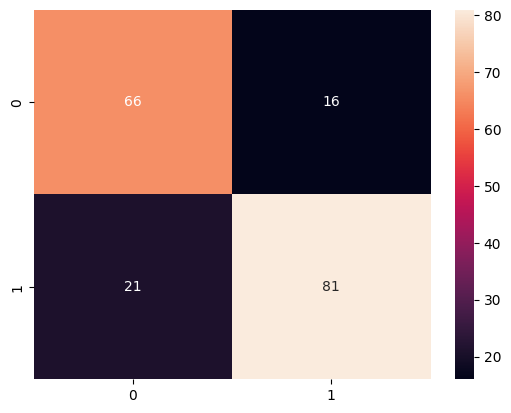

In [89]:
sns.heatmap(confusion_matrix(y_test,y_pred_tree),annot=True)

In [94]:
print(
        "ROC-AUC:",
        roc_auc_score(y_test, y_prob_tree)
    )

ROC-AUC: 0.7994978479196557


In [90]:
vot=VotingClassifier(estimators=[('log_reg',log_reg),('RanForst',RanForst),('tree',tree)],voting='soft')
vot.fit(X_train_scaled,y_train)

VotingClassifier(estimators=[('log_reg', LogisticRegression(max_iter=1000)),
                             ('RanForst',
                              RandomForestClassifier(random_state=42)),
                             ('tree',
                              DecisionTreeClassifier(criterion='entropy',
                                                     random_state=42))],
                 voting='soft')

In [91]:
y_pred_vot=vot.predict(X_test_scaled)
y_prob_vot = vot.predict_proba(
    X_test_scaled
)[:, 1]
print("Accuracy:",accuracy_score(y_test,y_pred_vot))
print("confusion Matrix",confusion_matrix(y_test,y_pred_vot))
print("Precision:",precision_score(y_test,y_pred_vot))
print("Recall:",recall_score(y_test,y_pred_vot))
print("F1 Score:",f1_score(y_test,y_pred_vot))


Accuracy: 0.8532608695652174
confusion Matrix [[68 14]
 [13 89]]
Precision: 0.8640776699029126
Recall: 0.8725490196078431
F1 Score: 0.8682926829268293


<Axes: >

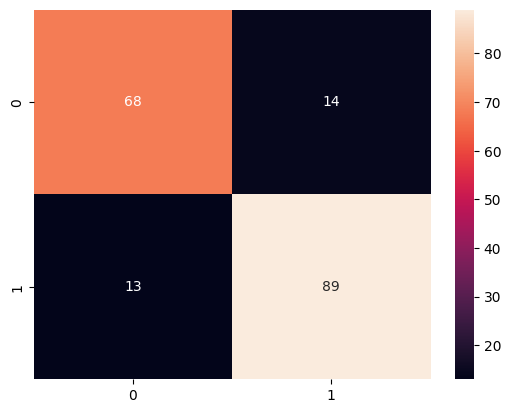

In [92]:
sns.heatmap(confusion_matrix(y_test,y_pred_vot),annot=True)

In [93]:
print(
        "ROC-AUC:",
        roc_auc_score(y_test, y_prob_vot)
    )

ROC-AUC: 0.9163079866092779


In [97]:
fpr_log, tpr_log, _ = roc_curve(
    y_test,
    y_prob_log
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

fpr_tree, tpr_tree, _ = roc_curve(
    y_test,
    y_prob_tree
)

fpr_voting, tpr_voting, _ = roc_curve(
    y_test,
    y_prob_vot
)


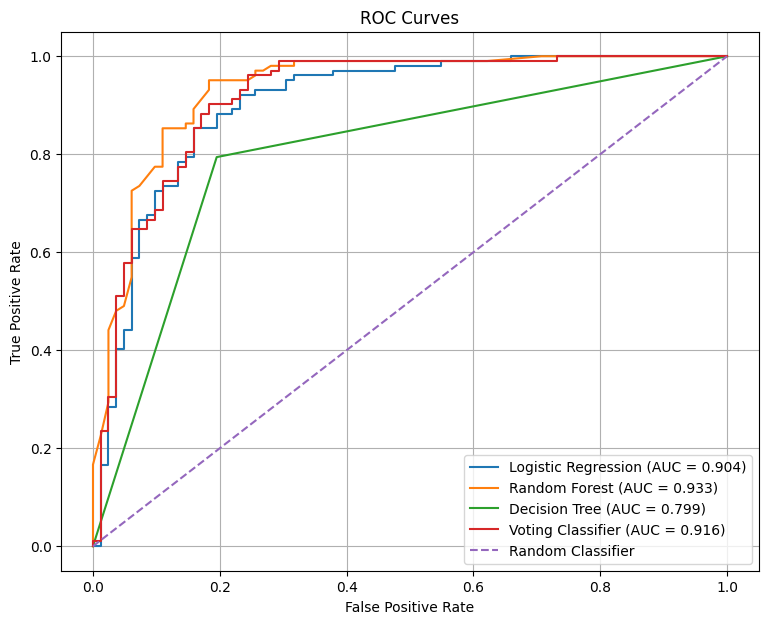

In [99]:
plt.figure(figsize=(9, 7))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_log):.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})"
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC = {roc_auc_score(y_test, y_prob_tree):.3f})"
)

plt.plot(
    fpr_voting,
    tpr_voting,
    label=f"Voting Classifier (AUC = {roc_auc_score(y_test, y_prob_vot):.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curves")

plt.legend()

plt.grid()

plt.show()